                    manager  manager id            stock  shares  shares outstanding  ownership  price        value
       VANGUARD GROUP, INC.       90457   MICROSOFT CORP 672.863              7434.0       9.05 446.95 300736.11785
              BLACKROCK INC        9385   MICROSOFT CORP 549.274              7434.0       7.39 430.30 236352.60220
       VANGUARD GROUP, INC.       90457      NVIDIA CORP 212.288              2500.0       8.49 903.56 191814.94528
              BLACKROCK INC        9385      NVIDIA CORP 178.570              2500.0       7.14 903.56 161348.70920
      STATE STR CORPORATION       81540   MICROSOFT CORP 300.031              7434.0       4.04 446.95 134098.85545
FIDELITY MGMT & RESEARCH CO       27800      NVIDIA CORP 115.104              2500.0       4.60 903.56 104003.37024
FIDELITY MGMT & RESEARCH CO       27800   MICROSOFT CORP 211.630              7434.0       2.85 430.30  91064.38900
      STATE STR CORPORATION       81540      NVIDIA CORP  90.489        

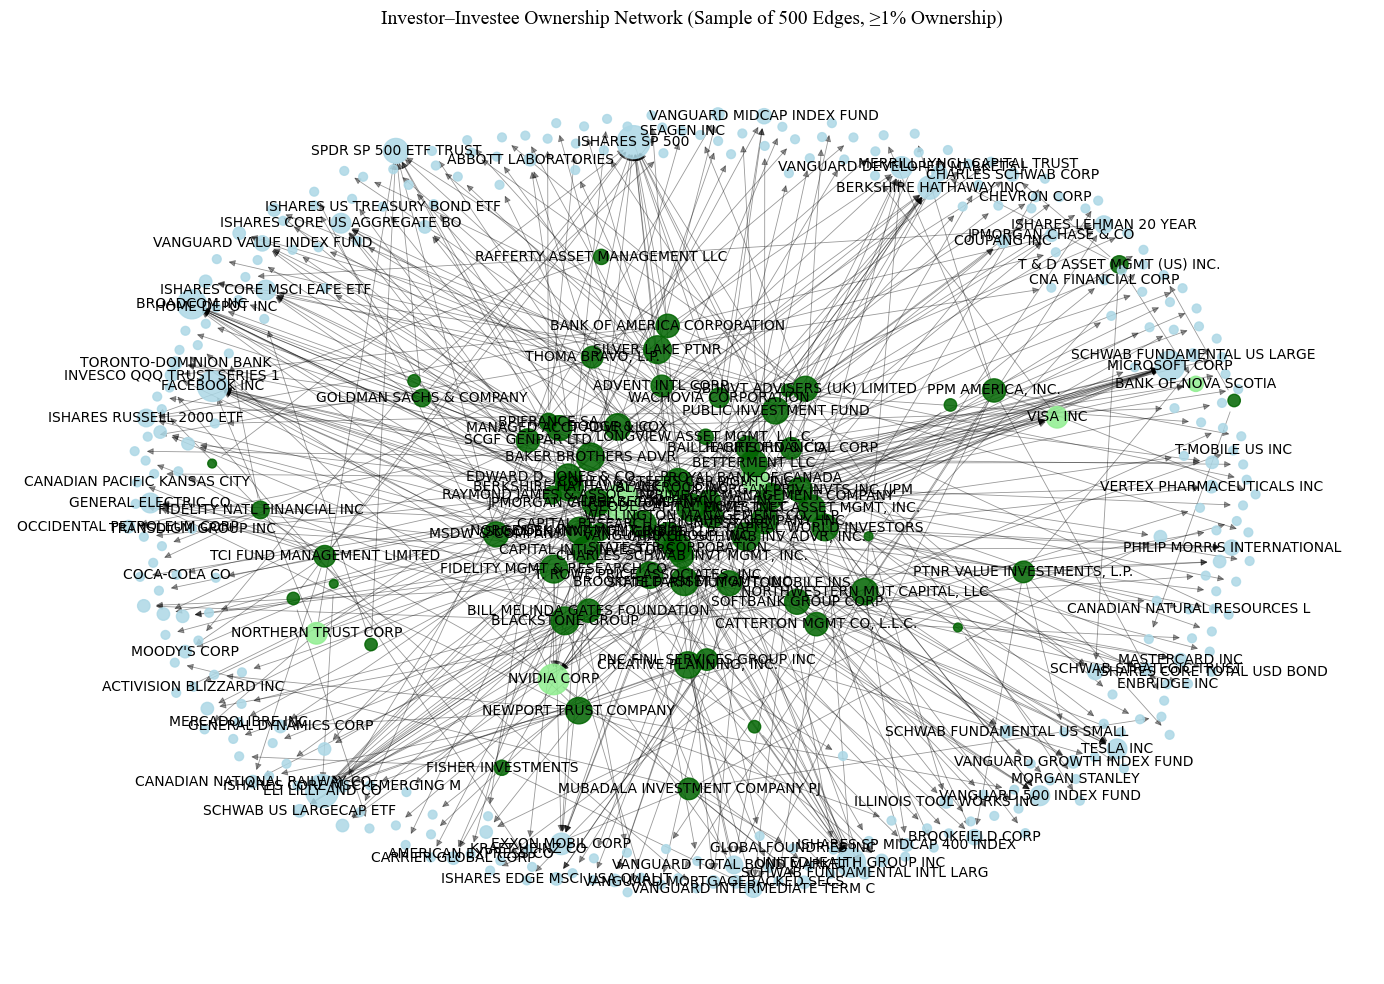

In [1]:
## BASIC LOWLY-FILTERED NETWORK OF OWNERSHIP

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
from collections import defaultdict


##Step 0-3 load and clean column names

# Step 0: Resolve the current path (works in notebooks or scripts)
try:
    notebook_dir = os.path.dirname(__file__)
except NameError:
    notebook_dir = os.getcwd()  # fallback for Jupyter notebooks

# Step 1: Build the full file path
file_path = os.path.join(notebook_dir, "WRDS_complete.csv")

# Step 2: Load the dataset
df = pd.read_csv(file_path)

# Step 3 a: Clean and print column names
df.columns = [col.strip().lower().replace("(", "").replace(")", "") for col in df.columns]

# Step 3 b: Rename for ease
df = df.rename(columns={
    'mgrname manager name': 'manager',
    'mgrno manager number': 'manager id',
    'rdate report date': 'report date',
    'stkname stock name': 'stock',
    'shares shares held at end of qtr': 'shares',
    'indcode industry code': 'industry',
    'prc share price, as of fdate': 'price',
    'shrout1 shares outstanding in millions, as of fdate': 'shares outstanding'
})


##Step 4-6 Select, convert, filter relevant columns

# Step 4: Filter relevant data and ensure numeric
df_filtered = df[['manager', 'manager id', 'report date', 'stock', 'shares', 'industry', 'price', 'shares outstanding']].dropna()
df_filtered['shares'] = pd.to_numeric(df_filtered['shares'], errors='coerce')
df_filtered['shares outstanding'] = pd.to_numeric(df_filtered['shares outstanding'], errors='coerce') * 1_000_000  # convert to absolute

# Step 5: Calculate ownership percentage
df_filtered['ownership'] = (df_filtered['shares'] / df_filtered['shares outstanding']) * 100
df_filtered = df_filtered.dropna(subset=['ownership'])
df_filtered = df_filtered[df_filtered['ownership'] <= 100]

# Step 6: Show example output
example_output = df_filtered[['manager', 'manager id', 'report date', 'stock', 'shares', 'price', 'shares outstanding', 'ownership', 'industry']].copy()
example_output['ownership'] = example_output['ownership'].round(4)

# Filter out invalid values
df_filtered = df_filtered.dropna(subset=['ownership'])         # Remove NaNs
df_filtered = df_filtered[df_filtered['ownership'] <= 100]     # Keep only valid ownership ≤ 100%



##Deduplication and aggregation:

# Sort and display top 20 by ownership
top_ownership = df_filtered.sort_values(by='ownership', ascending=False).head(20)

# Sort so the row with the highest 'shares outstanding' comes first
df_filtered = df_filtered.sort_values(by='shares outstanding', ascending=False)

# Drop duplicates by keeping the first (i.e., highest 'shares outstanding')
df_deduplicated = df_filtered.drop_duplicates(subset=['manager', 'stock'], keep='first')

# Make a proper copy to avoid Setting With Copy Warning
df_deduplicated = df_deduplicated.copy()

# Convert shares and shares outstanding to millions
df_deduplicated['shares'] = df_deduplicated['shares'] / 1_000_000
df_deduplicated['shares outstanding'] = df_deduplicated['shares outstanding'] / 1_000_000

# Round ownership to 2 decimal place
df_deduplicated['ownership'] = df_deduplicated['ownership'].round(2)

# Round shares and shares outstanding to 3 decimal place
df_deduplicated['shares'] = df_deduplicated['shares'].round(3)
df_deduplicated['shares outstanding'] = df_deduplicated['shares outstanding'].round(3)


##Add Value and Trim Dataset:
# Add column with value of each holding, ensuring both columns are numeric
df_deduplicated['price'] = pd.to_numeric(df_deduplicated['price'], errors='coerce')
df_deduplicated['shares'] = pd.to_numeric(df_deduplicated['shares'], errors='coerce')

# Create new column: value = shares * price
df_deduplicated['value'] = df_deduplicated['shares'] * df_deduplicated['price']

# Sort by 'value' and keep top 500
df_deduplicated = (
    df_deduplicated.sort_values(by='value', ascending=False)
    .groupby('manager')
    .head(10)  # increase breadth
    .reset_index(drop=True)
)
print(df_deduplicated[['manager', 'manager id', 'stock', 'shares', 'shares outstanding', 'ownership', 'price', 'value']].head(10).to_string(index=False))



## Step 7-11 Build ownership network:

# Step 7: Filter by significant ownership
ownership_threshold = 1  # percent
df_filtered_threshold = df_deduplicated[df_deduplicated['ownership'] >= ownership_threshold].copy()

# Step 8: Build directed single-mode ownership network
G = nx.DiGraph()

# Create a directed graph: Manager → Stock with edge attributes (weight, shares, value)
for _, row in df_filtered_threshold.iterrows():
    investor = row['manager']
    investee = row['stock']
    G.add_edge(investor, investee,
               weight=row['ownership'],
               shares=row['shares'],
               value=row['value'])
print(f"Graph built (threshold {ownership_threshold}%): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Step 9: Assign roles to nodes: visual interpretation and potential role-based filtering (e.g., identify cross-holdings or mutual fund-of-fund structures)
investors = set(df_filtered_threshold['manager'])
investees = set(df_filtered_threshold['stock'])

node_roles = {}
for node in G.nodes():
    if node in investors and node in investees:
        node_roles[node] = 'both'
    elif node in investors:
        node_roles[node] = 'investor'
    elif node in investees:
        node_roles[node] = 'investee'
    else:
        node_roles[node] = 'other'

nx.set_node_attributes(G, node_roles, name='role')

# Step 10: Create and visualize a sample subgraph to keep plot legible
sample_edges = list(G.edges(data=True))[:500]
G_sample = nx.DiGraph()
for u, v, attr in sample_edges:
    G_sample.add_edge(u, v, **attr)
edge_weights = [attr['weight'] / 2 for _, _, attr in G_sample.edges(data=True)]

# Step 11: Assign layout first, then colors, then node sizes by type and degree
# Layout
pos = nx.spring_layout(G_sample, seed=42, k=0.6)
matplotlib.rcParams["font.family"] = "Times New Roman"
matplotlib.rcParams["font.size"] = 12

# Colours
node_colors = []
for node in G_sample.nodes():
    role = G.nodes[node].get('role', 'other')
    if role == 'investor':
        node_colors.append('#006400')   # dark green
    elif role == 'investee':
        node_colors.append('#ADD8E6')   # light blue
    elif role == 'both':
        node_colors.append('#90EE90')   # light green
    else:
        node_colors.append('#CCCCCC')   # light gray
# Node sizes
node_sizes = [G_sample.degree(n) * 40 for n in G_sample.nodes()]

# Set labelling logic
# Set a dynamic threshold by market cap
market_cap_threshold = df_filtered_threshold['value'].quantile(0.99)
# Build a dictionary of market caps from df_filtered_threshold
value_map = df_filtered_threshold.groupby('stock')['value'].sum().to_dict()
# Get list of investors for cross-check
investors_set = set(df_filtered_threshold['manager'])
# Write label logic
labels_to_show = {}
for node in G_sample.nodes():
    role = G.nodes[node].get('role', 'other')
    deg = G_sample.degree(node)

    if role in ['investor', 'both']:
        # Check if connected to another investor
        neighbors = list(G_sample.successors(node)) + list(G_sample.predecessors(node))
        connected_to_investor = any(n in investors_set for n in neighbors)
        if deg > 2 or connected_to_investor:
            labels_to_show[node] = node

    elif role == 'investee':
        value = value_map.get(node, 0)
        if value >= market_cap_threshold:
            labels_to_show[node] = node

# Draw graph
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G_sample, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_sample, pos, alpha=0.4, width=0.6, arrows=True)
nx.draw_networkx_labels(G_sample, pos, labels=labels_to_show, font_size=10)

plt.title(f"Investor–Investee Ownership Network (Sample of 500 Edges, ≥{ownership_threshold}% Ownership)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
df_filtered_threshold.to_csv("final_deduplicated_holdings.csv", index=False)